In [4]:
import os
import numpy as np
import d3rlpy
import csv
import matplotlib.pyplot as plt

def read_Episodes(baseFolder):
    episodes = []
    for filename in sorted(os.listdir(baseFolder)):
        filePath = os.path.join(baseFolder, filename)
        episode = []
        with open(filePath, "r", newline="") as file:
            reader = csv.reader(file)
            next(reader)  # Skip header row
            for row in reader:
                observation = [float(epi) for epi in row]
                episode.append(observation)
            episodes.append(episode)
    return episodes

def load_models_from_training(training_dir):
    models = []
    model_files = sorted([f for f in os.listdir(training_dir) if f.endswith('.d3')])
    
    if len(model_files) > 10:
        step = (len(model_files) - 1) / 9
        selected_indices = [int(i * step) for i in range(9)]
        selected_indices.append(len(model_files) - 1)
        selected_indices = sorted(list(set(selected_indices)))
        model_files = [model_files[i] for i in selected_indices]
    for i,model_file in enumerate(model_files):
        model_path = os.path.join(training_dir, model_file)
        try:
            model = d3rlpy.load_learnable(model_path)
            models.append(((str(i)+model_file), model))
        except Exception as e:
            print(f"Error loading {model_file}: {e}")
    return models


Processing algorithm: BCQ_20260115190126
Keine Differenzen für 0model_1000.d3 (BCQ_20260115190126) zum Plotten vorhanden. Fehlerhafte Episoden: 5


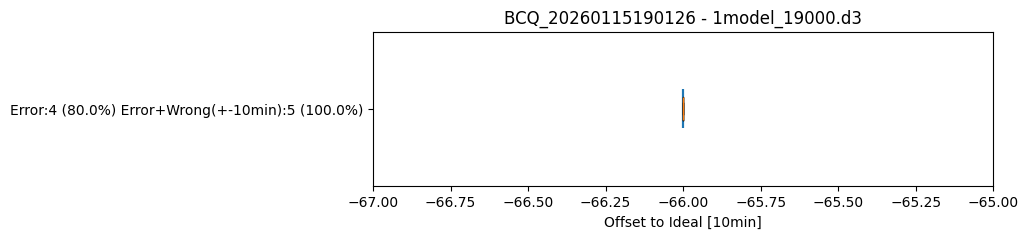

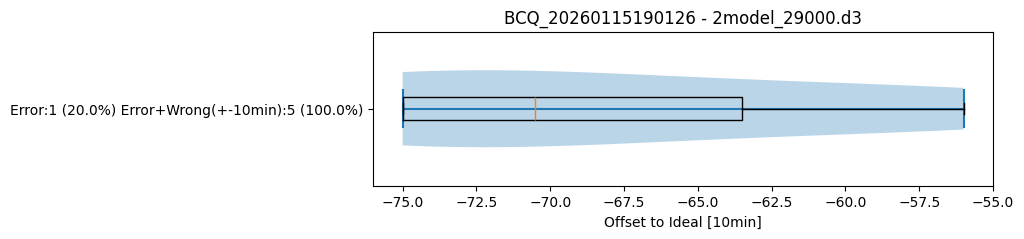

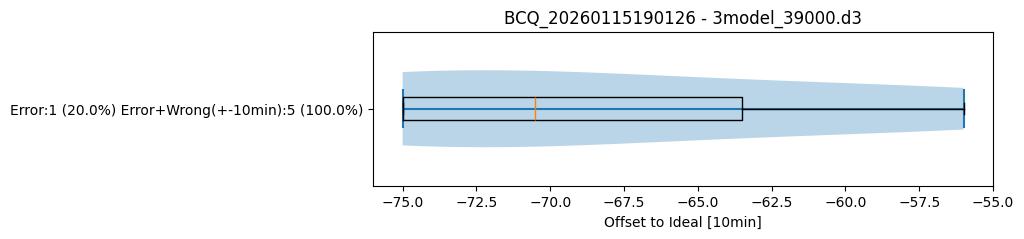

KeyboardInterrupt: 

In [3]:
#ToDo neues Datenset erzeugen mit nur idealen episoden um herauszufinden wie gut die Modelle wirklich sind 
#ToDo aus den real dAten muss auch ein datensatz gemacht werden um zu schauen wie gut die Modelle auf real daten sind
#      Dabei auf die Werte achten muss seleb Form wie bei den Trainingsdaten haben

# ==== Hauptfunktion ====
base_dir = "test logs"  # Passe ggf. an
#testEpisode = "../data/episFormula/3.2 test für 2.0/"  # Passe ggf. an
testEpisode = "../data/episFormula/test"  # Passe ggf. an


if os.path.exists(base_dir):
    algorithm_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    for algorithm_name in algorithm_dirs:
        # Arrays für spätere Auswertung
        model_names = []
        algo_names = []
        error_rates = []
        not_identified_rates = []
        total_error_rates = []
        algorithm_path = os.path.join(base_dir, algorithm_name)
        print(f"\nProcessing algorithm: {algorithm_name}")
        models = load_models_from_training(algorithm_path)
        if not models:
            print(f"No models found in {algorithm_path}")
            continue
        episodes = read_Episodes(testEpisode)
        for i, (model_name, model) in enumerate(models):
            soll_ist_diff = []
            totalError = 0
            not_identified = 0
            wrongEpisode = 0
            for samples in episodes:
                prediction = []
                for sample in samples:
                    obs = np.array([sample[:-3]])
                    try:
                        pred = model.predict(obs)[0]
                    except Exception as e:
                        pred = 0
                    prediction.append(pred)
                soll_idx = next((i for i, v in enumerate([sample[-1] for sample in samples]) if v > 0), None)
                ist_idx = next((i for i, v in enumerate(prediction) if v <= 10), None)
                if  ist_idx is None:
                    totalError += 1
                elif soll_idx is None:
                    wrongEpisode += 1
                    Warning("Soll Index nicht gefunden in Episode")
                else:
                    abweichung = ist_idx + 1 - soll_idx
                    soll_ist_diff.append(abweichung)
                    if not (-1 <= abweichung <= 1):
                        not_identified += 1
            n_valid = len(episodes) - wrongEpisode
            if len(soll_ist_diff) > 0 and n_valid > 0:
                wrong_predicted = ((totalError + not_identified) / n_valid) * 100
                error_percent = (totalError / n_valid) * 100
                not_identified_percent = (not_identified / n_valid) * 100
                # Arrays befüllen
                model_names.append(model_name)
                algo_names.append(algorithm_name)
                error_rates.append(error_percent)
                not_identified_rates.append(not_identified_percent)
                total_error_rates.append(wrong_predicted)
                plt.figure(figsize=(8,2))
                plt.violinplot(soll_ist_diff, vert=False)
                plt.boxplot(soll_ist_diff, vert=False, tick_labels=[f"Error:{totalError} ({error_percent:.1f}%) Error+Wrong(+-10min):{not_identified+totalError} ({wrong_predicted:.1f}%)"])
                plt.title(f"{algorithm_name} - {model_name}")
                plt.xlabel("Offset to Ideal [10min]")
                plt.xlim(min(soll_ist_diff) - 1, max(soll_ist_diff) + 1)
                plt.show()
            else:
                print(f"Keine Differenzen für {model_name} ({algorithm_name}) zum Plotten vorhanden. Fehlerhafte Episoden: {totalError}")

        # Zusammenfassende Visualisierung
        import pandas as pd
        plt.figure(figsize=(12,6))
        #reset parameters for
        summary_df = pd.DataFrame({
            "Algorithmus": algo_names,
            "Modell": model_names,
            "Error %": error_rates,
            "NotIdentified %": not_identified_rates,
            "Total Error %": total_error_rates
        })
        x = np.arange(len(summary_df))
        width = 0.25
        plt.bar(x - width, summary_df["Error %"], width=width, label="Error %")
        plt.bar(x, summary_df["NotIdentified %"], width=width, label="NotIdentified %")
        plt.bar(x + width, summary_df["Total Error %"], width=width, label="Error+NotIdentified %")
        plt.xticks(x, [f"{a}\n{m}" for a, m in zip(summary_df["Algorithmus"], summary_df["Modell"])], rotation=45, ha="right")
        plt.ylabel("Rate [%]")
        plt.title("Fehlerraten pro Modell und Algorithmus")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print(f"Directory {base_dir} not found!")

c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\d3rlpy\torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_locatio

Modell geladen: model_99000.d3
Anzahl geladener Episoden: 5

=== Testergebnisse ===
Modell: model_99000.d3
Test-Episoden: 5
Gültige Episoden: 5
Fehlerhafte Episoden: 0
Fehlerrate (Prediction Error): 20.00%
Nicht erkannt (±10min): 60.00%
Gesamtfehlerrate: 80.00%
Mittlere Abweichung: -53.75 ±31.82 in]


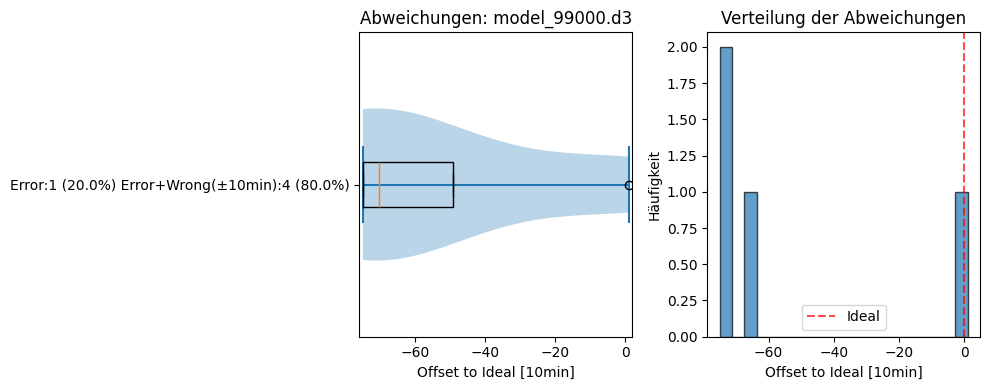

In [3]:
def test_csv_folder_against_latest_model(csv_folder, model_folder):
    """
    Testet CSV-Dateien aus einem Ordner gegen das neueste Modell in einem Modell-Ordner.
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien (Episoden)
        model_folder (str): Pfad zum Ordner mit Modellen (.d3 Dateien)
    
    Returns:
        dict: Dictionary mit Testergebnissen
    """
    
    # Lade das neueste Modell
    model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.d3')])
    if not model_files:
        print(f"Keine Modelle in {model_folder} gefunden!")
        return None
    
    latest_model_file = model_files[-1]  # Nimmt das letzte (neueste) Modell
    model_path = os.path.join(model_folder, latest_model_file)
    
    try:
        model = d3rlpy.load_learnable(model_path)
        print(f"Modell geladen: {latest_model_file}")
    except Exception as e:
        print(f"Fehler beim Laden des Modells {latest_model_file}: {e}")
        return None
    
    # Lade die Test-Episoden
    try:
        episodes = read_Episodes(csv_folder)
        print(f"Anzahl geladener Episoden: {len(episodes)}")
    except Exception as e:
        print(f"Fehler beim Laden der Episoden aus {csv_folder}: {e}")
        return None
    
    # Teste das Modell gegen die Episoden
    results = {
        'model_name': latest_model_file,
        'model_path': model_path,
        'csv_folder': csv_folder,
        'total_episodes': len(episodes),
        'soll_ist_differences': [],
        'total_errors': 0,
        'not_identified': 0,
        'wrong_episodes': 0
    }
    
    for episode_idx, samples in enumerate(episodes):
        prediction = []
        
        # Vorhersagen für alle Samples in der Episode
        for sample in samples:
            obs = np.array([sample[:-3]])  # Alle Features außer den letzten 3 (reward, terminal, ?)
            try:
                pred = model.predict(obs)[0]
            except Exception as e:
                pred = 0
            prediction.append(pred)
        
        # Finde den Soll-Index (wo terminal=1 oder reward>0?)
        soll_idx = next((i for i, v in enumerate([sample[-1] for sample in samples]) if v > 0), None)
        
        # Finde den Ist-Index (erste Vorhersage <= 10)
        ist_idx = next((i for i, v in enumerate(prediction) if v <= 10), None)
        
        if ist_idx is None:
            results['total_errors'] += 1
        elif soll_idx is None:
            results['wrong_episodes'] += 1
            print(f"Warnung: Soll-Index nicht gefunden in Episode {episode_idx}")
        else:
            abweichung = ist_idx + 1 - soll_idx
            results['soll_ist_differences'].append(abweichung)
            if not (-1 <= abweichung <= 1):
                results['not_identified'] += 1
    
    # Berechne Fehlerraten
    n_valid = results['total_episodes'] - results['wrong_episodes']
    if n_valid > 0:
        results['error_rate'] = (results['total_errors'] / n_valid) * 100
        results['not_identified_rate'] = (results['not_identified'] / n_valid) * 100
        results['total_error_rate'] = ((results['total_errors'] + results['not_identified']) / n_valid) * 100
    else:
        results['error_rate'] = 0
        results['not_identified_rate'] = 0
        results['total_error_rate'] = 0
    
    # Ausgabe der Ergebnisse
    print(f"\n=== Testergebnisse ===")
    print(f"Modell: {results['model_name']}")
    print(f"Test-Episoden: {results['total_episodes']}")
    print(f"Gültige Episoden: {n_valid}")
    print(f"Fehlerhafte Episoden: {results['wrong_episodes']}")
    print(f"Fehlerrate (Prediction Error): {results['error_rate']:.2f}%")
    print(f"Nicht erkannt (±10min): {results['not_identified_rate']:.2f}%")
    print(f"Gesamtfehlerrate: {results['total_error_rate']:.2f}%")
    
    if results['soll_ist_differences']:
        print(f"Mittlere Abweichung: {np.mean(results['soll_ist_differences']):.2f} ±{np.std(results['soll_ist_differences']):.2f} [10min]")
    
    return results

def visualize_test_results(results):
    """
    Visualisiert die Testergebnisse.
    
    Args:
        results (dict): Rückgabe von test_csv_folder_against_latest_model
    """
    if results is None or not results['soll_ist_differences']:
        print("Keine Daten zum Visualisieren vorhanden.")
        return
    
    soll_ist_diff = results['soll_ist_differences']
    
    # Violin/Box Plot
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.violinplot(soll_ist_diff, vert=False)
    plt.boxplot(soll_ist_diff, vert=False, 
                tick_labels=[f"Error:{results['total_errors']} ({results['error_rate']:.1f}%) "
                           f"Error+Wrong(±10min):{results['total_errors']+results['not_identified']} "
                           f"({results['total_error_rate']:.1f}%)"])
    plt.title(f"Abweichungen: {results['model_name']}")
    plt.xlabel("Offset to Ideal [10min]")
    plt.xlim(min(soll_ist_diff) - 1, max(soll_ist_diff) + 1)
    
    # Histogramm
    plt.subplot(1, 2, 2)
    plt.hist(soll_ist_diff, bins=20, alpha=0.7, edgecolor='black')
    plt.title("Verteilung der Abweichungen")
    plt.xlabel("Offset to Ideal [10min]")
    plt.ylabel("Häufigkeit")
    plt.axvline(0, color='red', linestyle='--', alpha=0.7, label='Ideal')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Beispiel für die Verwendung:
results = test_csv_folder_against_latest_model("../data/episFormula/test", "test logs/PLAS_20260116030234")
visualize_test_results(results)

In [9]:
def plot_single_day_progression(episode, episode_index, model, model_name):
    """
    Plottet den Tagesverlauf einer einzelnen Episode.
    
    Args:
        episode (list): Episode Daten
        episode_index (int): Index der Episode
        model: Das geladene Modell
        model_name (str): Name des Modells
    """
    
    # Extrahiere Daten aus der Episode
    abstimes = [sample[1] for sample in episode]  # abstime column (absolute time in minutes)
    times = [sample[2] for sample in episode]  # time column (relative time)
    time_to_irri_actual = [sample[7] for sample in episode]  # timeToIrri column
    terminals = [sample[9] for sample in episode]  # terminal column
    
    # Generiere Vorhersagen
    predictions = []
    for sample in episode:
        obs = np.array([sample[:-3]])  # Alle Features außer den letzten 3
        try:
            pred = model.predict(obs)[0]
            # Stelle sicher, dass pred ein Skalar ist
            if isinstance(pred, np.ndarray):
                pred = pred.item() if pred.size == 1 else pred[0]
            elif hasattr(pred, '__len__') and len(pred) > 0:
                pred = pred[0]
        except Exception as e:
            pred = 0
        predictions.append(float(pred))
    
    # Finde Bewässerungszeitpunkte
    irrigation_times = [abstimes[i] for i, terminal in enumerate(terminals) if terminal > 0]
    
    # Erstelle das Diagramm
    plt.figure(figsize=(15, 8))
    
    # Subplot 1: timeToIrri Vergleich
    plt.subplot(2, 1, 1)
    plt.plot(abstimes, time_to_irri_actual, 'b-', linewidth=2, label='Tatsächliche timeToIrri')
    plt.plot(abstimes, predictions, 'r--', linewidth=2, alpha=0.7, label='Modell Vorhersage')
    
    # Markiere Bewässerungszeitpunkte
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Zeit bis Bewässerung (Minuten)')
    plt.title(f'Tag {episode_index + 1}: timeToIrri vs. Modellvorhersage (mit abstime)\nModell: {model_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Differenz zwischen Vorhersage und Realität
    plt.subplot(2, 1, 2)
    differences = [float(pred) - float(actual) for pred, actual in zip(predictions, time_to_irri_actual)]
    plt.plot(abstimes, differences, 'purple', linewidth=1.5, alpha=0.8)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    plt.fill_between(abstimes, differences, alpha=0.3, color='purple')
    
    # Markiere Bewässerungszeitpunkte auch hier
    for irr_time in irrigation_times:
        plt.axvline(x=irr_time, color='green', linestyle=':', alpha=0.7, linewidth=2)
    
    plt.xlabel('Absolute Zeit (Minuten)')
    plt.ylabel('Differenz (Vorhersage - Tatsächlich)')
    plt.title('Differenz zwischen Modellvorhersage und tatsächlicher timeToIrri')
    plt.grid(True, alpha=0.3)
    
    # Füge Text mit Statistiken hinzu
    mean_diff = np.mean(differences)
    std_diff = np.std(differences)
    max_diff = max(differences)
    min_diff = min(differences)
    
    stats_text = f'Mittlere Abweichung: {mean_diff:.2f}±{std_diff:.2f} min\nMax: {max_diff:.2f}, Min: {min_diff:.2f}'
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Zeige auch einige Statistiken
    print(f"\n=== Statistiken für Tag {episode_index + 1} ===")
    print(f"Anzahl Datenpunkte: {len(episode)}")
    print(f"Anzahl Bewässerungen: {len(irrigation_times)}")
    print(f"Mittlere Abweichung: {mean_diff:.2f} ± {std_diff:.2f} Minuten")
    print(f"Maximale Abweichung: {max_diff:.2f} Minuten")
    print(f"Minimale Abweichung: {min_diff:.2f} Minuten")
    
    return {
        'episode_index': episode_index,
        'mean_diff': mean_diff,
        'std_diff': std_diff,
        'max_diff': max_diff,
        'min_diff': min_diff,
        'num_irrigations': len(irrigation_times),
        'num_datapoints': len(episode)
    }

def plot_all_daily_progressions(csv_folder, model_folder, max_episodes=None):
    """
    Plottet den Tagesverlauf für alle Episoden mit separaten Diagrammen pro Tag.
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien
        model_folder (str): Pfad zum Ordner mit Modellen
        max_episodes (int): Maximale Anzahl von Episoden zu plotten (None für alle)
    """
    
    # Lade das neueste Modell
    model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.d3')])
    if not model_files:
        print(f"Keine Modelle in {model_folder} gefunden!")
        return
    
    latest_model_file = model_files[-1]
    model_path = os.path.join(model_folder, latest_model_file)
    
    try:
        model = d3rlpy.load_learnable(model_path)
        print(f"Modell geladen: {latest_model_file}")
    except Exception as e:
        print(f"Fehler beim Laden des Modells: {e}")
        return
    
    # Lade die Episoden
    episodes = read_Episodes(csv_folder)
    total_episodes = len(episodes)
    
    # Begrenze die Anzahl wenn gewünscht
    if max_episodes is not None:
        episodes = episodes[:max_episodes]
        print(f"Plotte die ersten {len(episodes)} von {total_episodes} verfügbaren Episoden")
    else:
        print(f"Plotte alle {total_episodes} verfügbaren Episoden")
    
    # Sammle Statistiken über alle Tage
    all_stats = []
    
    # Plotte jeden Tag separat
    for episode_index, episode in enumerate(episodes):
        print(f"\nPlotte Tag {episode_index + 1} von {len(episodes)}...")
        stats = plot_single_day_progression(episode, episode_index, model, latest_model_file)
        all_stats.append(stats)
    
    # Zeige Zusammenfassung über alle Tage
    print(f"\n{'='*50}")
    print(f"ZUSAMMENFASSUNG ÜBER ALLE {len(episodes)} TAGE")
    print(f"{'='*50}")
    
    mean_diffs = [stat['mean_diff'] for stat in all_stats]
    std_diffs = [stat['std_diff'] for stat in all_stats]
    max_diffs = [stat['max_diff'] for stat in all_stats]
    min_diffs = [stat['min_diff'] for stat in all_stats]
    
    print(f"Durchschnittliche mittlere Abweichung: {np.mean(mean_diffs):.2f} ± {np.std(mean_diffs):.2f} Minuten")
    print(f"Durchschnittliche Standardabweichung: {np.mean(std_diffs):.2f} ± {np.std(std_diffs):.2f} Minuten")
    print(f"Größte Abweichung über alle Tage: {max(max_diffs):.2f} Minuten (Tag {np.argmax(max_diffs) + 1})")
    print(f"Kleinste Abweichung über alle Tage: {min(min_diffs):.2f} Minuten (Tag {np.argmin(min_diffs) + 1})")
    
    total_irrigations = sum(stat['num_irrigations'] for stat in all_stats)
    total_datapoints = sum(stat['num_datapoints'] for stat in all_stats)
    print(f"Gesamtanzahl Bewässerungen: {total_irrigations}")
    print(f"Gesamtanzahl Datenpunkte: {total_datapoints}")
    
    # Erstelle Übersichtsdiagramm über alle Tage
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Mittlere Abweichung pro Tag
    plt.subplot(2, 2, 1)
    days = [stat['episode_index'] + 1 for stat in all_stats]
    plt.plot(days, mean_diffs, 'bo-', alpha=0.7)
    plt.xlabel('Tag')
    plt.ylabel('Mittlere Abweichung [min]')
    plt.title('Mittlere Abweichung pro Tag')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Standardabweichung pro Tag
    plt.subplot(2, 2, 2)
    plt.plot(days, std_diffs, 'ro-', alpha=0.7)
    plt.xlabel('Tag')
    plt.ylabel('Standardabweichung [min]')
    plt.title('Standardabweichung pro Tag')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Max/Min Abweichung pro Tag
    plt.subplot(2, 2, 3)
    plt.plot(days, max_diffs, 'g^-', alpha=0.7, label='Maximum')
    plt.plot(days, min_diffs, 'gv-', alpha=0.7, label='Minimum')
    plt.xlabel('Tag')
    plt.ylabel('Abweichung [min]')
    plt.title('Min/Max Abweichung pro Tag')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Anzahl Bewässerungen pro Tag
    plt.subplot(2, 2, 4)
    irrigations_per_day = [stat['num_irrigations'] for stat in all_stats]
    plt.bar(days, irrigations_per_day, alpha=0.7, color='cyan')
    plt.xlabel('Tag')
    plt.ylabel('Anzahl Bewässerungen')
    plt.title('Anzahl Bewässerungen pro Tag')
    plt.grid(True, alpha=0.3)
    
    plt.suptitle(f'Übersicht über alle {len(episodes)} Tage - Modell: {latest_model_file}', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return all_stats

def plot_daily_progression_with_predictions(csv_folder, model_folder, episode_index=0):
    """
    Plottet den Tagesverlauf einer Episode mit timeToIrri und Modellvorhersagen.
    (Behält die ursprüngliche Funktion für Rückwärtskompatibilität)
    
    Args:
        csv_folder (str): Pfad zum Ordner mit CSV-Dateien
        model_folder (str): Pfad zum Ordner mit Modellen
        episode_index (int): Index der Episode die geplottet werden soll
    """
    
    # Lade das neueste Modell
    model_files = sorted([f for f in os.listdir(model_folder) if f.endswith('.d3')])
    if not model_files:
        print(f"Keine Modelle in {model_folder} gefunden!")
        return
    
    latest_model_file = model_files[-1]
    model_path = os.path.join(model_folder, latest_model_file)
    
    try:
        model = d3rlpy.load_learnable(model_path)
        print(f"Modell geladen: {latest_model_file}")
    except Exception as e:
        print(f"Fehler beim Laden des Modells: {e}")
        return
    
    # Lade die Episoden
    episodes = read_Episodes(csv_folder)
    if episode_index >= len(episodes):
        print(f"Episode {episode_index} nicht gefunden. Verfügbare Episoden: 0-{len(episodes)-1}")
        return
    
    episode = episodes[episode_index]
    return plot_single_day_progression(episode, episode_index, model, latest_model_file)

# Verwende die Funktion mit Ihren Daten
#plot_daily_progression_with_predictions("../data/episFormula/test", "test logs/PLAS_20260116030234", episode_index=0)

c:\Users\NilsWindows\Desktop\research2.0\.venv\lib\site-packages\d3rlpy\torch_utility.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chkpt = torch.load(f, map_locatio

Modell geladen: model_99000.d3
Plotte die ersten 5 von 5 verfügbaren Episoden

Plotte Tag 1 von 5...


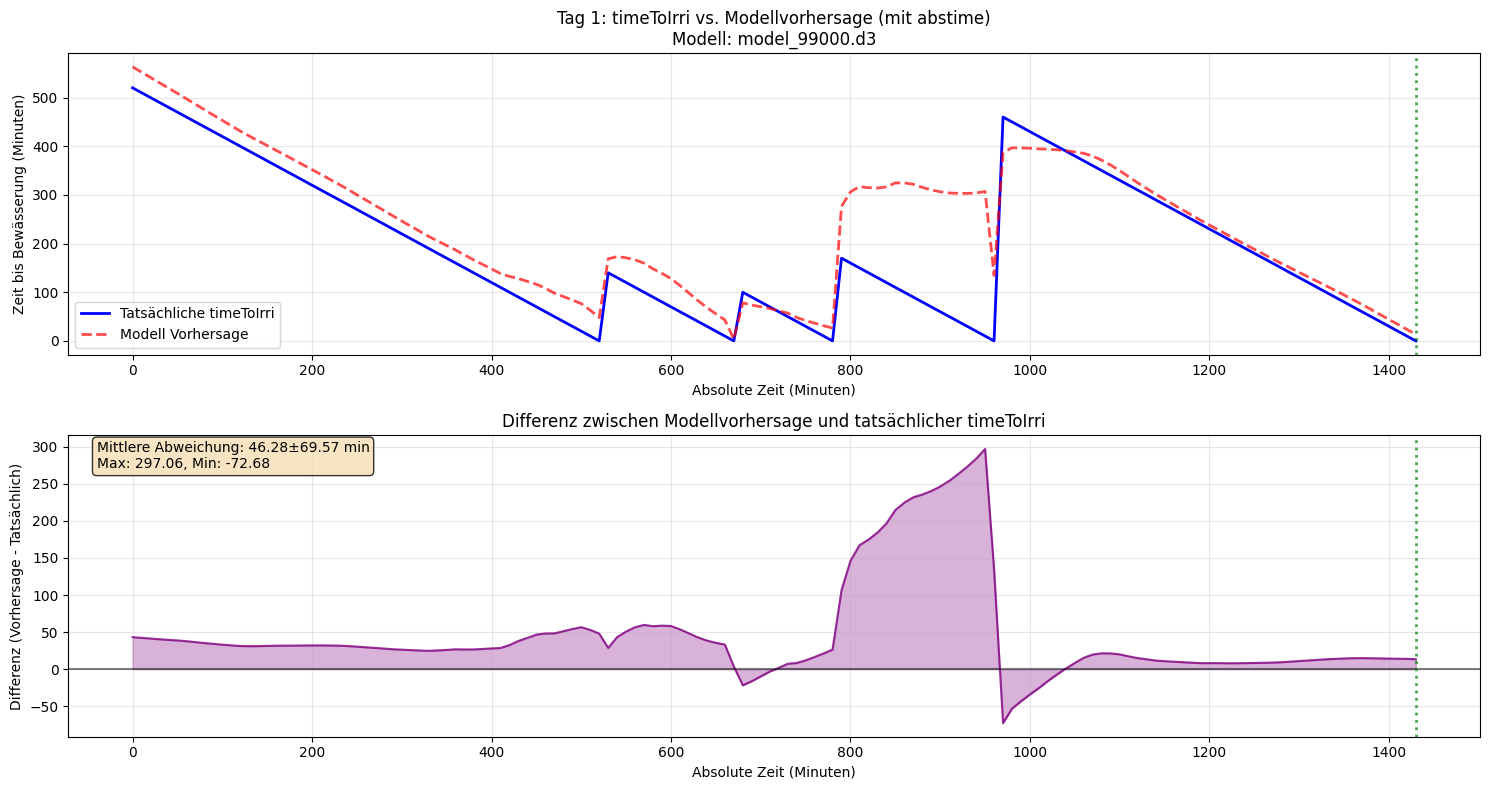


=== Statistiken für Tag 1 ===
Anzahl Datenpunkte: 144
Anzahl Bewässerungen: 1
Mittlere Abweichung: 46.28 ± 69.57 Minuten
Maximale Abweichung: 297.06 Minuten
Minimale Abweichung: -72.68 Minuten

Plotte Tag 2 von 5...


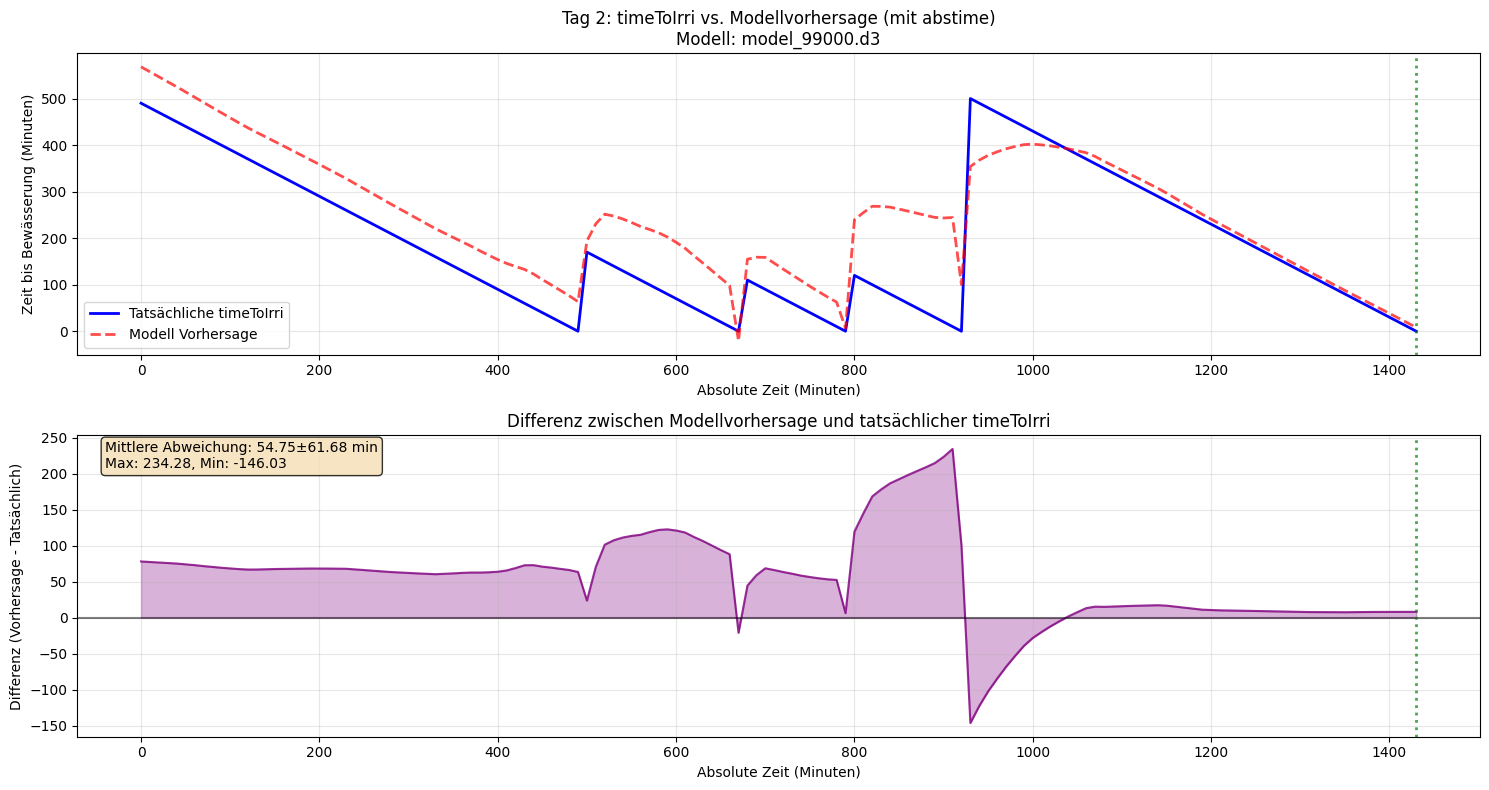


=== Statistiken für Tag 2 ===
Anzahl Datenpunkte: 144
Anzahl Bewässerungen: 1
Mittlere Abweichung: 54.75 ± 61.68 Minuten
Maximale Abweichung: 234.28 Minuten
Minimale Abweichung: -146.03 Minuten

Plotte Tag 3 von 5...


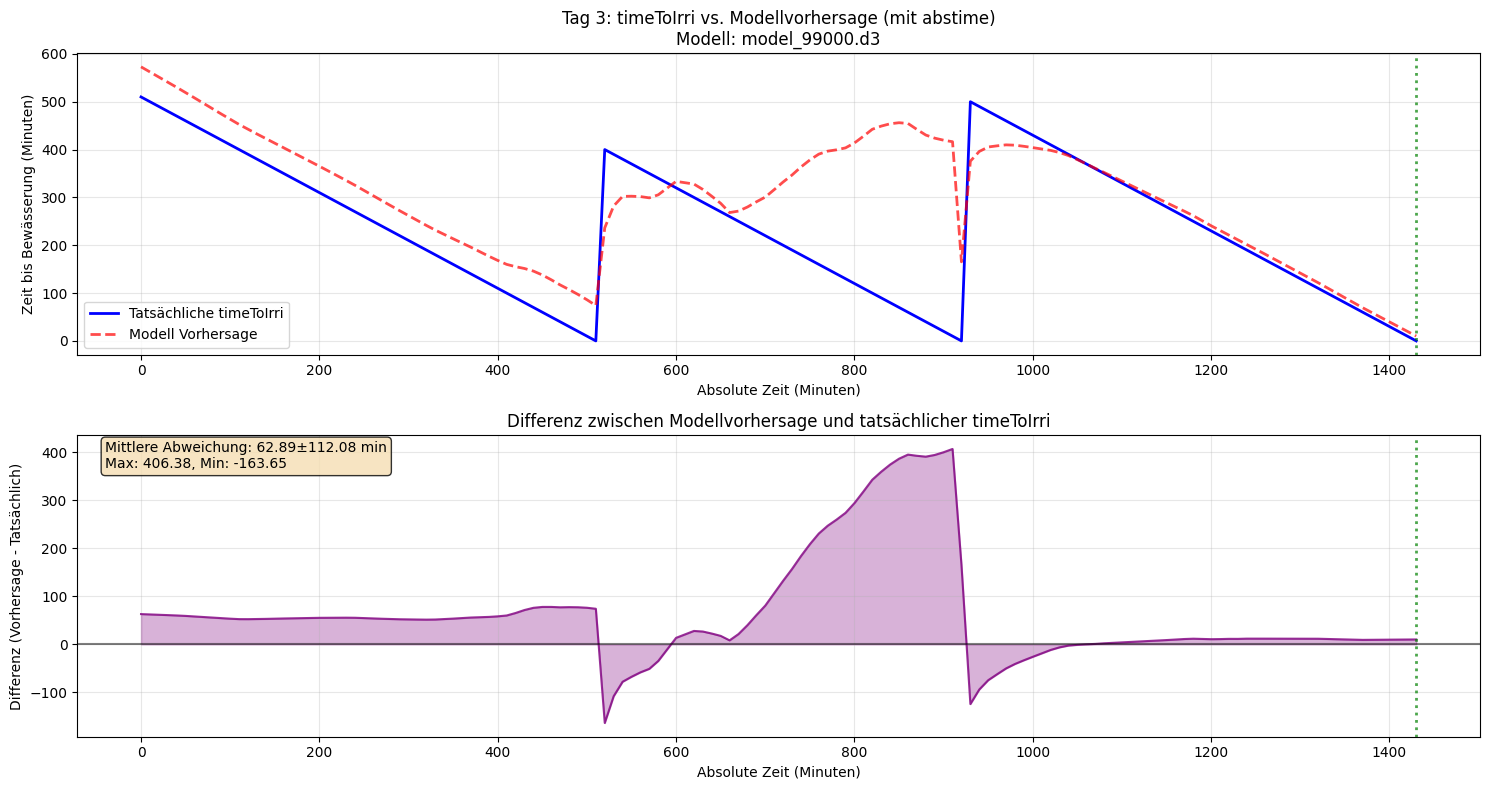


=== Statistiken für Tag 3 ===
Anzahl Datenpunkte: 144
Anzahl Bewässerungen: 1
Mittlere Abweichung: 62.89 ± 112.08 Minuten
Maximale Abweichung: 406.38 Minuten
Minimale Abweichung: -163.65 Minuten

Plotte Tag 4 von 5...


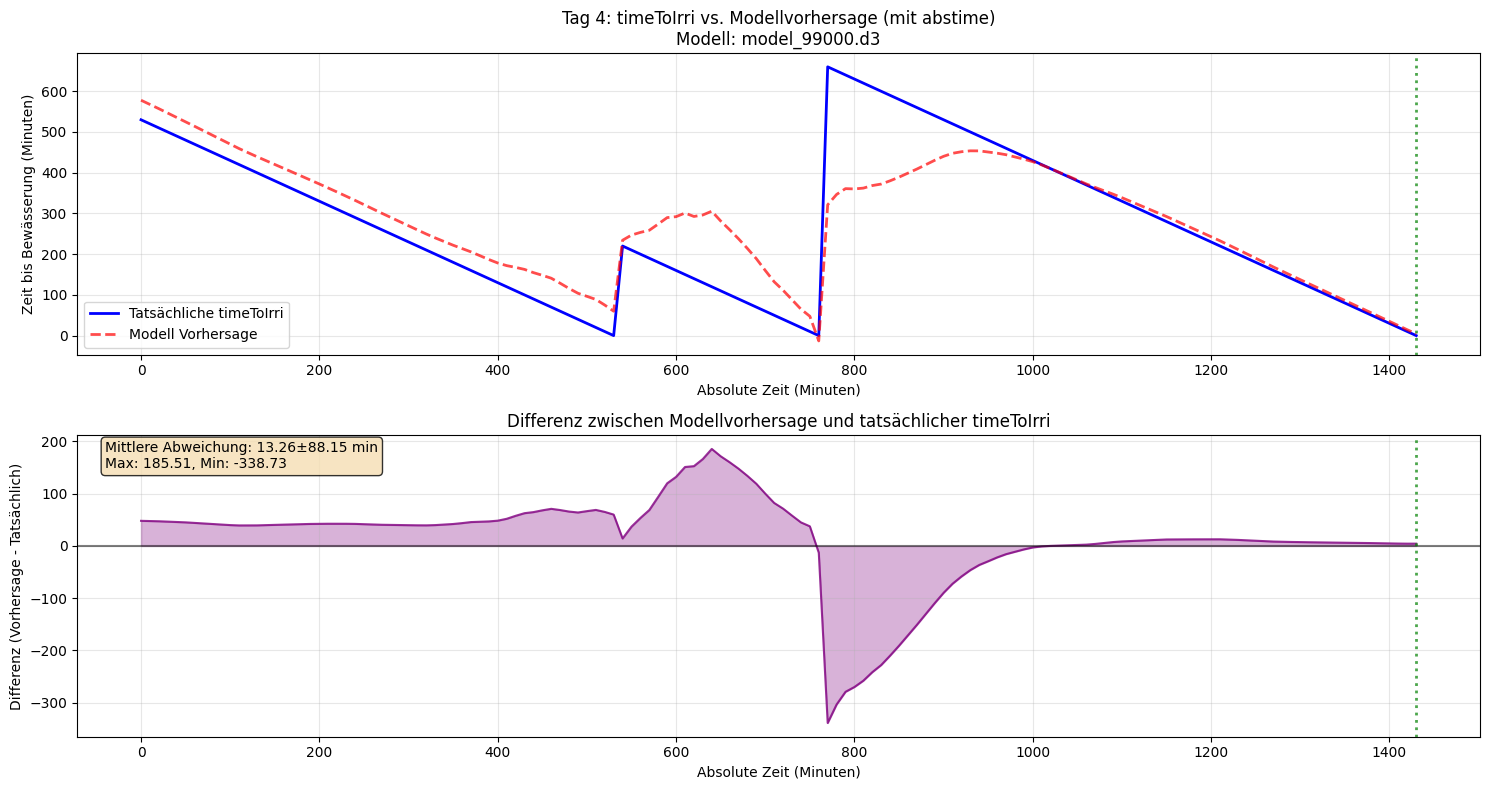


=== Statistiken für Tag 4 ===
Anzahl Datenpunkte: 144
Anzahl Bewässerungen: 1
Mittlere Abweichung: 13.26 ± 88.15 Minuten
Maximale Abweichung: 185.51 Minuten
Minimale Abweichung: -338.73 Minuten

Plotte Tag 5 von 5...


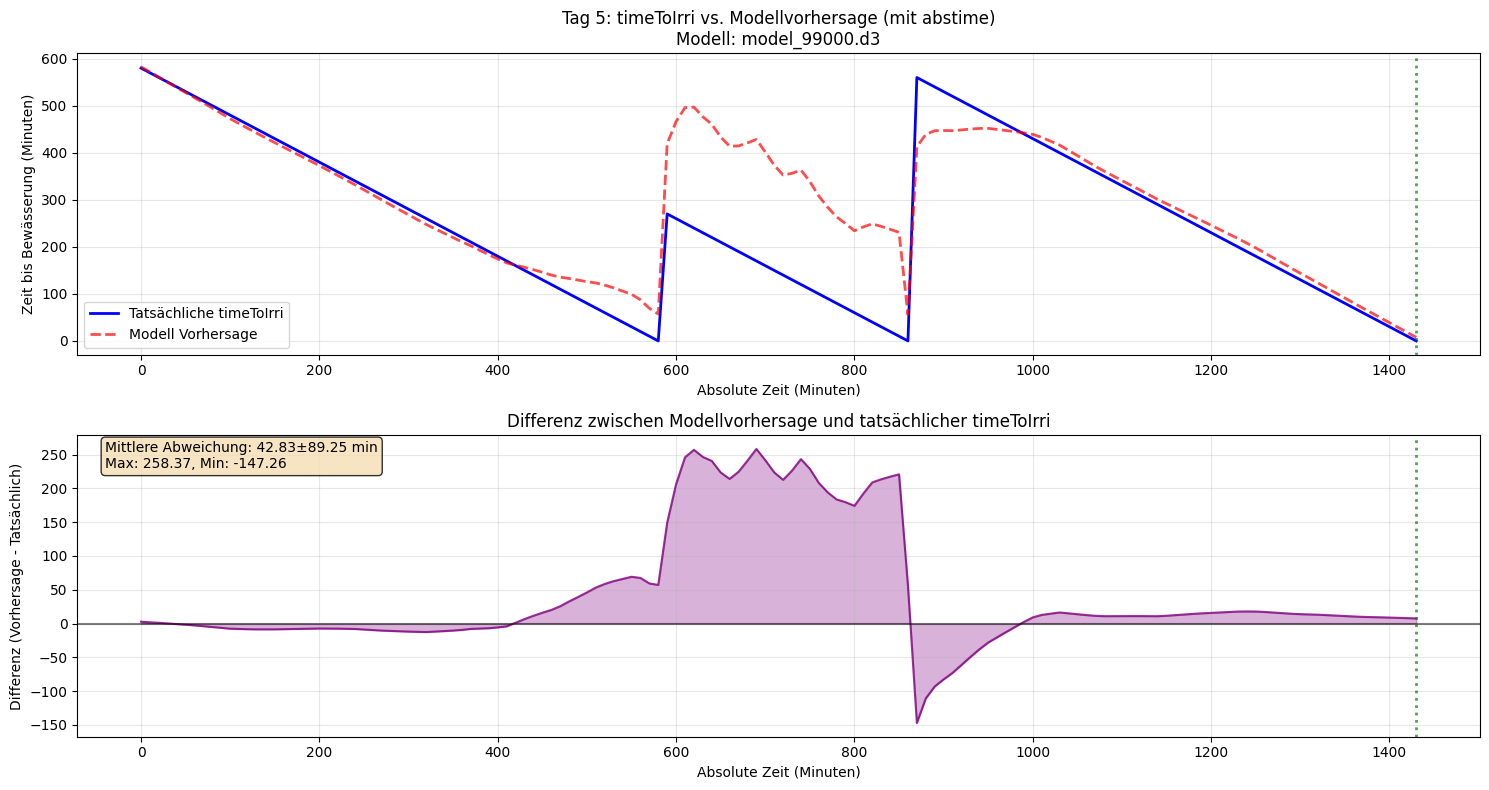


=== Statistiken für Tag 5 ===
Anzahl Datenpunkte: 144
Anzahl Bewässerungen: 1
Mittlere Abweichung: 42.83 ± 89.25 Minuten
Maximale Abweichung: 258.37 Minuten
Minimale Abweichung: -147.26 Minuten

ZUSAMMENFASSUNG ÜBER ALLE 5 TAGE
Durchschnittliche mittlere Abweichung: 44.00 ± 16.88 Minuten
Durchschnittliche Standardabweichung: 84.15 ± 17.55 Minuten
Größte Abweichung über alle Tage: 406.38 Minuten (Tag 3)
Kleinste Abweichung über alle Tage: -338.73 Minuten (Tag 4)
Gesamtanzahl Bewässerungen: 5
Gesamtanzahl Datenpunkte: 720


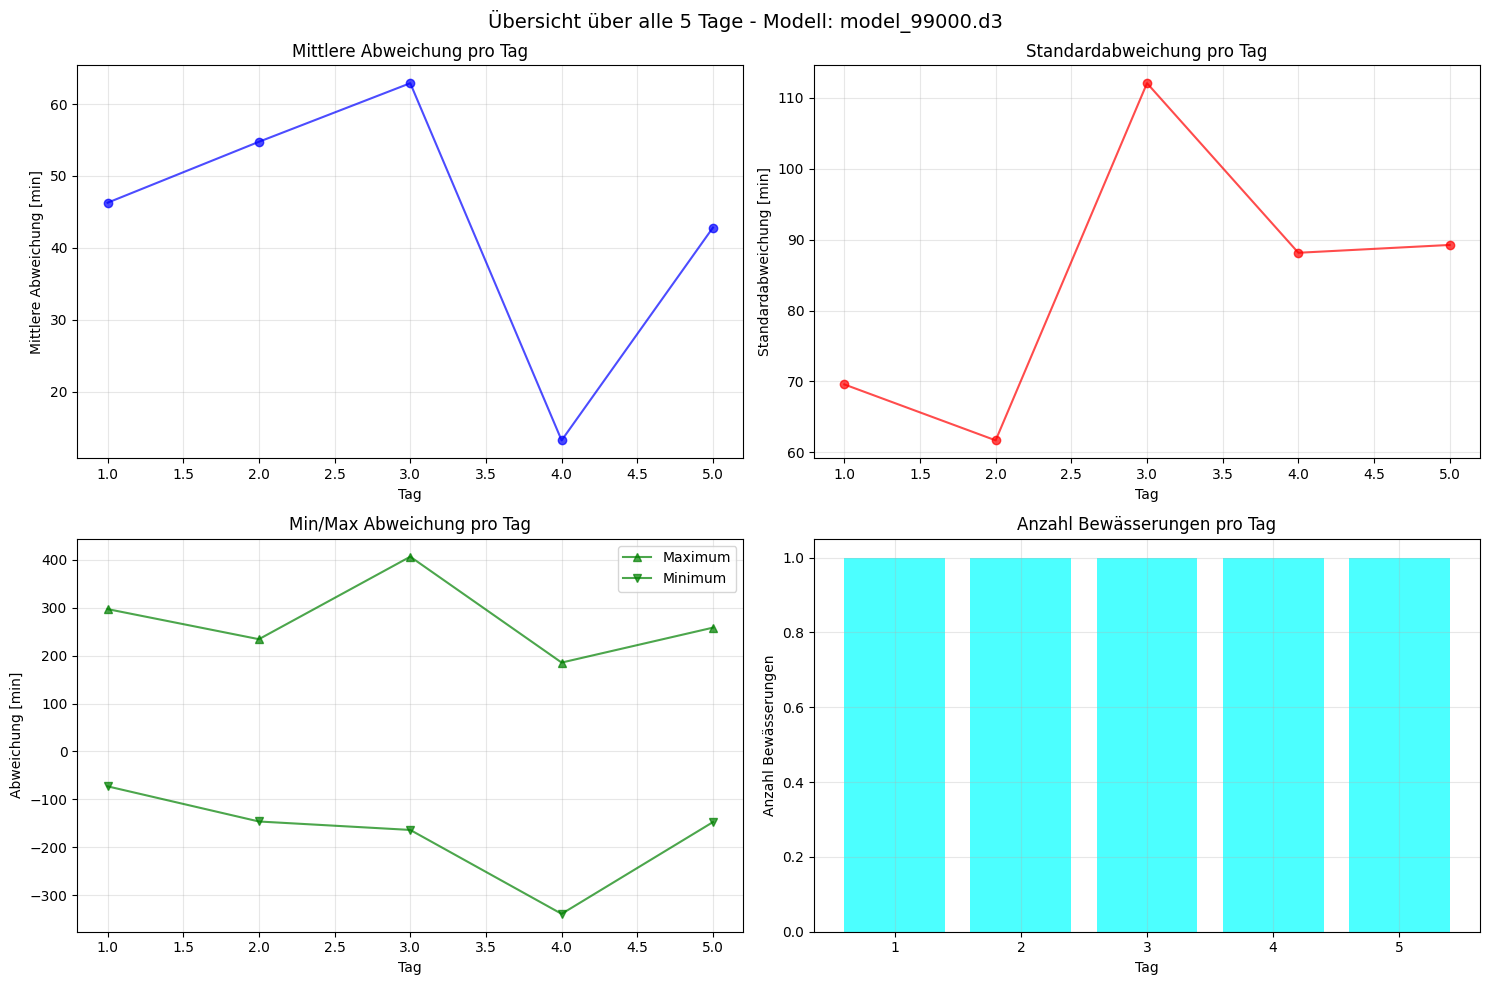

In [11]:
# Plotte alle verfügbaren Tage (begrenzt auf die ersten 10 für bessere Performance)
all_stats = plot_all_daily_progressions("../data/episFormula/test", "test logs/PLAS_20260116030234", max_episodes=10)